# Breast Thermography 3D Reconstruction (DMR-IR) - Orthographic Geometric Pipeline

**Scope:** Pure geometric 2.5D reconstruction from five segmented thermal views (0 deg, +/-45 deg, +/-90 deg).  
**Goal:** Reconstruct a smooth 3D NURBS-like breast surface and extract asymmetry descriptors for downstream NNMF-ReliefF and Ensemble CNN analysis.  
**Framework:** NumPy + PyTorch + SciPy (edge-computing friendly).

---

## Protocol lock (Moura VISAPP 2024/2025 aligned)

1. Input is a 1-pixel skeletonized contour from semantic segmentation (256x256).
2. Phase 3 uses anatomical anchors (P1, P2, P3) with strict lateral clipping.
3. Phase 4 rotates around anatomical pivots (never camera center).
4. Phase 4 follows Algorithm 1 rigid registration: move local P2 to origin, rotate, then translate to frontal P1 or P3 target anchor.
5. Phase 5 surface interpolation uses B-spline fitting with degree 4 (`kx=4`, `ky=4`) and evaluation step `0.01` in parametric space.
6. Phase 6 outputs numeric geometry features, not only rendered figures.

This notebook includes reference functions that follow these constraints directly.

---

## Phase 1 - Data Loading and Normalization

This phase pairs each thermal TIFF with its binary mask, resizes both to $256 \times 256$, and converts them to tensors suitable for U-Net input.

The thermal image is min-max normalized to preserve temperature contrast while mapping values into a stable learning range:

$$
m_{ij} = \frac{P_{ij} - \min(P)}{\max(P) - \min(P)}
$$

This is equivalent to the paper's normalized intensity step before model training.

In [10]:
%pip install torch torchvision tifffile opencv-python scikit-learn matplotlib pandas seaborn tensorflow keras cv2


/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [11]:
pip install opencv-python

/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


### 1.1 ThermalDataset class

The dataset class performs three important jobs:

1. Finds mask files recursively and uses them as the reference sample list.
2. Locates each TIFF robustly using filename-prefix matching to avoid Unicode mismatches (for example degree-symbol variants).
3. Returns image-mask pairs as shape $(1, H, W)$ tensors so they are immediately compatible with the U-Net input/output format.

This design is intentionally defensive for Windows path and encoding edge cases.

In [12]:
import torch
import torch.nn as nn
import torch.optim as optim
import torchvision.transforms.functional as TF
from torch.utils.data import Dataset, DataLoader, random_split
import tifffile as tiff
import cv2
import numpy as np
import os
import glob

# ── FIX 2: Reproducibility seed ──────────────────────────────────────────────
SEED = 42
torch.manual_seed(SEED)
np.random.seed(SEED)


class ThermalDataset(Dataset):
    def __init__(self, tiff_dir, mask_dir):
        # We find all masks first as they represent our ground truth batch
        self.mask_paths = glob.glob(os.path.join(mask_dir, "**", "*.png"), recursive=True)
        self.tiff_dir = tiff_dir
        self.mask_dir = mask_dir
        print(f"Dataset initialized with {len(self.mask_paths)} masks.")

    def __len__(self):
        return len(self.mask_paths)

    def __getitem__(self, idx):
        mask_path = self.mask_paths[idx]

        # 1. Get the patient folder and filename (e.g., Patient_106/benign/Right Lateral...)
        rel_path = os.path.relpath(mask_path, self.mask_dir)
        patient_subfolder = os.path.dirname(rel_path)
        mask_filename = os.path.basename(rel_path)

        # 2. Robust TIFF Search: Find the TIFF that matches the mask name
        # We search the folder directly to avoid encoding mismatches with the degree symbol
        tiff_search_folder = os.path.join(self.tiff_dir, patient_subfolder)
        base_name = os.path.splitext(mask_filename)[0]

        # We use a wildcard search to find the .tiff file matching the start of the mask name
        # This bypasses the specific encoding of the (90°) part
        search_pattern = os.path.join(tiff_search_folder, "*.tiff")
        potential_tiffs = glob.glob(search_pattern)

        tiff_path = None
        for p_tiff in potential_tiffs:
            if base_name[:10] in os.path.basename(p_tiff):  # Match first 10 chars (e.g., 'Right Late')
                tiff_path = p_tiff
                break

        if tiff_path is None or not os.path.exists(tiff_path):
            raise FileNotFoundError(f"Could not find matching TIFF for {mask_path}")

        # 3. Load and Normalize TIFF (Paper Eq 1) [cite: 113]
        raw_data = tiff.imread(tiff_path)
        t_min, t_max = np.min(raw_data), np.max(raw_data)

        # Prevent division by zero
        if t_max == t_min:
            normalized = np.zeros_like(raw_data, dtype=np.float32)
        else:
            normalized = (raw_data - t_min) / (t_max - t_min)

        img_256 = cv2.resize(normalized.astype(np.float32), (256, 256), interpolation=cv2.INTER_AREA)

        # 4. Load Mask
        # Use np.fromfile to bypass Windows encoding issues with the degree symbol (°)
        img_array = np.fromfile(mask_path, dtype=np.uint8)
        mask = cv2.imdecode(img_array, cv2.IMREAD_GRAYSCALE)
        if mask is None:
            raise ValueError(f"Could not read mask file (might be corrupted or empty): {mask_path}")
        mask_256 = cv2.resize(mask, (256, 256)).astype(np.float32) / 255.0

        # Return as (C, H, W) tensors
        return torch.from_numpy(img_256).unsqueeze(0), torch.from_numpy(mask_256).unsqueeze(0)


# Paths in Thinkpad environment (adjust as needed)
TIFF_BASE = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient"
MASK_BASE = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/GroundTruth_Masks"

# ── FIX 1: Train / test split — 78 % / 22 % per paper §3.3 ──────────────────
full_dataset = ThermalDataset(TIFF_BASE, MASK_BASE)
n_total = len(full_dataset)
n_train = int(0.78 * n_total)
n_test  = n_total - n_train
train_set, test_set = random_split(
    full_dataset, [n_train, n_test],
    generator=torch.Generator().manual_seed(SEED)
)
print(f"Split: {n_train} train / {n_test} test  (total={n_total})")

train_loader = DataLoader(train_set, batch_size=2, shuffle=True)   # Batch size 2 as per paper
test_loader  = DataLoader(test_set,  batch_size=2, shuffle=False)


Dataset initialized with 162 masks.
Split: 126 train / 36 test  (total=162)


### 1.2 Training-time augmentation

To reduce overfitting on a limited medical dataset, augmentation is applied only to training batches.

- Horizontal flip is applied to both image and mask so spatial correspondence remains correct.
- Brightness jitter is applied only to the thermal image.

This keeps anatomical geometry valid while improving generalization.

In [13]:
import albumentations as A
import torch
import torchvision.transforms.functional as TF

# ── FIX 3: Advanced Data Augmentation (Albumentations) ────────────────────────
# This targets the >0.95 Dice goal using High-Intensity augmentation
train_transform = A.Compose([
    A.HorizontalFlip(p=0.5),
    A.ShiftScaleRotate(shift_limit=0.05, scale_limit=0.05, rotate_limit=15, p=0.5),
    A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
    A.RandomBrightnessContrast(p=0.5),
    A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.2), # Cutout
])

def augment(img_tensor, mask_tensor):
    """Applies Albumentations to the PyTorch tensors."""
    # Apply augmentation sample-by-sample so a batch of shape (B, 1, H, W) stays single-channel.
    if img_tensor.dim() == 3:
        img_tensor = img_tensor.unsqueeze(0)
        mask_tensor = mask_tensor.unsqueeze(0)

    augmented_imgs = []
    augmented_masks = []
    for img_item, mask_item in zip(img_tensor, mask_tensor):
        img_np = img_item.squeeze(0).cpu().numpy()
        mask_np = mask_item.squeeze(0).cpu().numpy()
        
        try:
            augmented = train_transform(image=img_np, mask=mask_np)
            img_aug = torch.from_numpy(augmented['image']).unsqueeze(0)
            mask_aug = torch.from_numpy(augmented['mask']).unsqueeze(0)
        except Exception:
            img_aug = img_item
            mask_aug = mask_item

        augmented_imgs.append(img_aug)
        augmented_masks.append(mask_aug)

    return torch.stack(augmented_imgs, dim=0), torch.stack(augmented_masks, dim=0)

/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv/lib/python3.11/site-packages/albumentations/core/validation.py:114: UserWarning: ShiftScaleRotate is a special case of Affine transform. Please use Affine transform instead.
  original_init(self, **validated_kwargs)
/tmp/ipykernel_19561/3807153830.py:10: UserWarning: Argument(s) 'alpha_affine' are not valid for transform ElasticTransform
  A.ElasticTransform(alpha=1, sigma=50, alpha_affine=50, p=0.5),
/tmp/ipykernel_19561/3807153830.py:12: UserWarning: Argument(s) 'max_holes, max_height, max_width' are not valid for transform CoarseDropout
  A.CoarseDropout(max_holes=8, max_height=16, max_width=16, p=0.2), # Cutout


---

## Phase 2 - U-Net Architecture (Stronger V2)

The model is now a **4-level encoder-decoder U-Net** with skip connections, BatchNorm, dropout regularization, and He initialization for better convergence stability.

Each block uses:

$\text{Conv}(3\times3) \rightarrow \text{BN} \rightarrow \text{ReLU} \rightarrow \text{Conv}(3\times3) \rightarrow \text{BN} \rightarrow \text{ReLU}$

### Channel flow

| Stage | Channels |
|---|---|
| Encoder 1 | 1 -> 64 |
| Encoder 2 | 64 -> 128 |
| Encoder 3 | 128 -> 256 |
| Encoder 4 | 256 -> 512 |
| Bottleneck | 512 -> 1024 |
| Decoder 4 | 1024 -> 512 |
| Decoder 3 | 512 -> 256 |
| Decoder 2 | 256 -> 128 |
| Decoder 1 | 128 -> 64 |
| Output | 64 -> 1 (logits) |

The output layer returns **logits** (no sigmoid in the model head). Sigmoid is applied only when computing Dice/visualization/inference thresholding.

In [14]:
import torch.nn as nn

class AttentionBlock(nn.Module):
    def __init__(self, F_g, F_l, F_int):
        super(AttentionBlock, self).__init__()
        self.W_g = nn.Sequential(
            nn.Conv2d(F_g, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.W_x = nn.Sequential(
            nn.Conv2d(F_l, F_int, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(F_int)
        )
        self.psi = nn.Sequential(
            nn.Conv2d(F_int, 1, kernel_size=1, stride=1, padding=0, bias=True),
            nn.BatchNorm2d(1),
            nn.Sigmoid()
        )
        self.relu = nn.ReLU(inplace=True)

    def forward(self, g, x):
        g1 = self.W_g(g)
        x1 = self.W_x(x)
        psi = self.relu(g1 + x1)
        psi = self.psi(psi)
        return x * psi

class DoubleConv(nn.Module):
    def __init__(self, in_c, out_c, dropout=0.0):
        super().__init__()
        self.block = nn.Sequential(
            nn.Conv2d(in_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Conv2d(out_c, out_c, kernel_size=3, padding=1, bias=False),
            nn.BatchNorm2d(out_c),
            nn.ReLU(inplace=True),
            nn.Dropout2d(dropout) if dropout > 0 else nn.Identity(),
        )
    def forward(self, x):
        return self.block(x)

class UNet(nn.Module):
    def __init__(self, in_channels=1, out_channels=1, base_channels=64, dropout=0.2):
        super().__init__()
        self.pool = nn.MaxPool2d(2)

        self.enc1 = DoubleConv(in_channels, base_channels, dropout=0.0)
        self.enc2 = DoubleConv(base_channels, base_channels * 2, dropout=0.0)
        self.enc3 = DoubleConv(base_channels * 2, base_channels * 4, dropout=0.1)
        self.enc4 = DoubleConv(base_channels * 4, base_channels * 8, dropout=0.1)

        self.bottleneck = DoubleConv(base_channels * 8, base_channels * 16, dropout=dropout)

        self.up4 = nn.ConvTranspose2d(base_channels * 16, base_channels * 8, kernel_size=2, stride=2)
        self.att4 = AttentionBlock(F_g=base_channels * 8, F_l=base_channels * 8, F_int=base_channels * 4)
        self.dec4 = DoubleConv(base_channels * 16, base_channels * 8, dropout=0.1)

        self.up3 = nn.ConvTranspose2d(base_channels * 8, base_channels * 4, kernel_size=2, stride=2)
        self.att3 = AttentionBlock(F_g=base_channels * 4, F_l=base_channels * 4, F_int=base_channels * 2)
        self.dec3 = DoubleConv(base_channels * 8, base_channels * 4, dropout=0.1)

        self.up2 = nn.ConvTranspose2d(base_channels * 4, base_channels * 2, kernel_size=2, stride=2)
        self.att2 = AttentionBlock(F_g=base_channels * 2, F_l=base_channels * 2, F_int=base_channels)
        self.dec2 = DoubleConv(base_channels * 4, base_channels * 2, dropout=0.0)

        self.up1 = nn.ConvTranspose2d(base_channels * 2, base_channels, kernel_size=2, stride=2)
        self.att1 = AttentionBlock(F_g=base_channels, F_l=base_channels, F_int=base_channels // 2)
        self.dec1 = DoubleConv(base_channels * 2, base_channels, dropout=0.0)

        self.out = nn.Conv2d(base_channels, out_channels, kernel_size=1)
        self.apply(self._init_weights)

    @staticmethod
    def _init_weights(module):
        if isinstance(module, (nn.Conv2d, nn.ConvTranspose2d)):
            nn.init.kaiming_normal_(module.weight, mode="fan_out", nonlinearity="relu")
            if module.bias is not None:
                nn.init.constant_(module.bias, 0)
        elif isinstance(module, nn.BatchNorm2d):
            nn.init.constant_(module.weight, 1)
            nn.init.constant_(module.bias, 0)

    def forward(self, x):
        e1 = self.enc1(x)
        e2 = self.enc2(self.pool(e1))
        e3 = self.enc3(self.pool(e2))
        e4 = self.enc4(self.pool(e3))
        b = self.bottleneck(self.pool(e4))

        u4 = self.up4(b)
        x4 = self.att4(g=u4, x=e4)
        d4 = self.dec4(torch.cat([u4, x4], dim=1))

        u3 = self.up3(d4)
        x3 = self.att3(g=u3, x=e3)
        d3 = self.dec3(torch.cat([u3, x3], dim=1))

        u2 = self.up2(d3)
        x2 = self.att2(g=u2, x=e2)
        d2 = self.dec2(torch.cat([u2, x2], dim=1))

        u1 = self.up1(d2)
        x1 = self.att1(g=u1, x=e1)
        d1 = self.dec1(torch.cat([u1, x1], dim=1))
        
        return self.out(d1)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
model = UNet().to(device)
num_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Attention U-Net ready on: {device} | trainable params: {num_params:,}")

Attention U-Net ready on: cuda | trainable params: 31,388,013


### 2.1 Dice coefficient metric

Binary cross-entropy is used for optimization, but Dice is the key overlap metric for segmentation quality.

Dice is computed as:

$$
\text{Dice} = \frac{2|A \cap B| + \epsilon}{|A| + |B| + \epsilon}
$$

where $A$ is the thresholded prediction and $B$ is the ground-truth mask.

In [15]:
# ── Dice coefficient that supports logits ─────────────────────────────────────
def dice_coeff(pred, target, threshold=0.5, eps=1e-6, from_logits=True):
    """Dice over batch. pred/target shape: (B,1,H,W)."""
    if from_logits:
        pred = torch.sigmoid(pred)
    pred_bin = (pred > threshold).float()

    intersection = (pred_bin * target).sum(dim=(1, 2, 3))
    denominator = pred_bin.sum(dim=(1, 2, 3)) + target.sum(dim=(1, 2, 3))
    dice = (2.0 * intersection + eps) / (denominator + eps)
    return dice.mean()

---

### 2.2 Training loop (AdamW + BCEWithLogits+Dice + early stopping)

| Hyperparameter | Value |
|---|---|
| Loss | $0.6\times\text{BCEWithLogits} + 0.4\times\text{DiceLoss}$ |
| Optimizer | AdamW |
| Learning rate | $3 \times 10^{-4}$ (adaptive via ReduceLROnPlateau) |
| Weight decay | $1 \times 10^{-4}$ |
| Batch size | 2 |
| Max epochs | 120 |
| Early stopping patience | 12 epochs without val-Dice improvement |
| Stability tricks | AMP (CUDA), gradient clipping (1.0) |

The loop logs train loss, train Dice, validation Dice, and learning rate.  
Best validation-Dice weights are saved immediately to preserve the strongest checkpoint.

Each fold also writes a JSON history file to `unet_training_history/`, so the training curves can be plotted again later without retraining.

The figure below shows the requested training curves for each fold: training loss and validation Dice score versus epoch. The dashed vertical line marks the early-stopping epoch for that fold.

In [16]:
%pip install tqdm ipywidgets


/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/.venv/bin/python: No module named pip
Note: you may need to restart the kernel to use updated packages.


In [17]:
from tqdm.notebook import tqdm  # Progress bar for Jupyter / VS Code

In [18]:
from sklearn.model_selection import KFold
import torch.nn.functional as F
import json
from pathlib import Path
import numpy as np

# --- Focal-Dice Loss Definition ---
class FocalDiceLoss(nn.Module):
    def __init__(self, focal_weight=0.5, dice_weight=0.5, gamma=2.0, alpha=0.25):
        super().__init__()
        self.focal_w = focal_weight
        self.dice_w = dice_weight
        self.gamma = gamma
        self.alpha = alpha

    def forward(self, logits, targets):
        bce_loss = F.binary_cross_entropy_with_logits(logits, targets, reduction='none')
        pt = torch.exp(-bce_loss)
        focal_loss = self.alpha * (1 - pt) ** self.gamma * bce_loss
        focal_loss = focal_loss.mean()

        probs = torch.sigmoid(logits)
        num = 2 * (probs * targets).sum(dim=(1,2,3))
        den = probs.sum(dim=(1,2,3)) + targets.sum(dim=(1,2,3)) + 1e-6
        dice_loss = 1 - (num / den).mean()

        return self.focal_w * focal_loss + self.dice_w * dice_loss, focal_loss, dice_loss

# --- K-Fold Settings ---
# FIX: K-fold runs on train_set (126 samples) only.
# test_set (36 samples) is held out and never touched during cross-validation.
k_folds = 5
num_epochs = 120
patience = 12
use_amp = device.type == "cuda"

kfold = KFold(n_splits=k_folds, shuffle=True, random_state=SEED)
fold_results = []
fold_histories = []
history_dir = Path("unet_training_history")
history_dir.mkdir(exist_ok=True)

for fold, (train_ids, val_ids) in enumerate(kfold.split(range(len(train_set)))):
    print(f"\n========== FOLD {fold+1}/{k_folds} ==========")
    print(f"  CV train: {len(train_ids)} | CV val: {len(val_ids)} | held-out test: {len(test_set)}")

    # Slice within train_set only — test_set indices are never touched
    train_sub = torch.utils.data.Subset(train_set, train_ids)
    val_sub   = torch.utils.data.Subset(train_set, val_ids)

    train_loader = DataLoader(train_sub, batch_size=2, shuffle=True)
    val_loader   = DataLoader(val_sub,   batch_size=2, shuffle=False)

    model     = UNet().to(device)
    optimizer = optim.AdamW(model.parameters(), lr=3e-4, weight_decay=1e-4)
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode="max", factor=0.5, patience=3, min_lr=1e-6)
    criterion = FocalDiceLoss(focal_weight=0.5, dice_weight=0.5)
    scaler    = torch.amp.GradScaler("cuda", enabled=use_amp)

    best_dice = 0.0
    best_epoch = 0
    epochs_no_imp = 0
    early_stop_epoch = None
    best_ckpt = f"unet_fold_{fold+1}.pth"
    train_loss_history = []
    val_dice_history = []

    for epoch in range(num_epochs):
        model.train()
        epoch_loss = 0.0
        epoch_dice = 0.0

        for imgs, masks in train_loader:
            imgs, masks = augment(imgs, masks)
            imgs, masks = imgs.to(device), masks.to(device)

            optimizer.zero_grad(set_to_none=True)
            with torch.amp.autocast("cuda", enabled=use_amp):
                logits = model(imgs)
                loss, _, _ = criterion(logits, masks)

            scaler.scale(loss).backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            scaler.step(optimizer)
            scaler.update()

            epoch_loss += loss.item()
            epoch_dice += dice_coeff(logits.detach(), masks, from_logits=True).item()

        avg_train_loss = epoch_loss / len(train_loader)
        avg_train_dice = epoch_dice / len(train_loader)
        train_loss_history.append(avg_train_loss)

        model.eval()
        val_dice = 0.0
        with torch.no_grad():
            for imgs, masks in val_loader:
                imgs, masks = imgs.to(device), masks.to(device)
                logits = model(imgs)
                val_dice += dice_coeff(logits, masks, from_logits=True).item()

        val_dice /= len(val_loader)
        val_dice_history.append(val_dice)
        scheduler.step(val_dice)

        if val_dice > best_dice:
            best_dice = val_dice
            best_epoch = epoch + 1
            epochs_no_imp = 0
            torch.save(model.state_dict(), best_ckpt)
        else:
            epochs_no_imp += 1
            if epochs_no_imp >= patience:
                early_stop_epoch = epoch + 1
                print(f"Early stopping fold {fold+1} at epoch {early_stop_epoch}.")
                break

        if (epoch + 1) % 10 == 0:
            print(f"Epoch {epoch+1:03d} | Train Loss: {avg_train_loss:.4f} | Train Dice: {avg_train_dice:.4f} | Val Dice: {val_dice:.4f}")

    print(f"Fold {fold+1} Best Val Dice: {best_dice:.4f} at epoch {best_epoch} -> Saved to {best_ckpt}")
    fold_results.append(best_dice)
    fold_history = {
        "fold": fold + 1,
        "train_loss": train_loss_history,
        "val_dice": val_dice_history,
        "best_epoch": best_epoch,
        "best_dice": best_dice,
        "early_stop_epoch": early_stop_epoch,
    }
    fold_histories.append(fold_history)
    with open(history_dir / f"fold_{fold+1}_history.json", "w", encoding="utf-8") as history_file:
        json.dump(fold_history, history_file, indent=2)

print("\n========== FINAL K-FOLD RESULTS (on CV val folds within train_set) ==========")
for i, res in enumerate(fold_results):
    print(f"Fold {i+1}: {res:.4f}")
print(f"Average CV Val Dice: {np.mean(fold_results):.4f} ± {np.std(fold_results):.4f}")
print(f"(Held-out test evaluation follows after ensemble generation.)")



========== FOLD 1/5 ==========
  CV train: 100 | CV val: 26 | held-out test: 36


Epoch 010 | Train Loss: 0.1151 | Train Dice: 0.8301 | Val Dice: 0.7980
Epoch 020 | Train Loss: 0.0783 | Train Dice: 0.8824 | Val Dice: 0.8323
Epoch 030 | Train Loss: 0.0630 | Train Dice: 0.9072 | Val Dice: 0.8412
Epoch 040 | Train Loss: 0.0551 | Train Dice: 0.9181 | Val Dice: 0.8586
Epoch 050 | Train Loss: 0.0518 | Train Dice: 0.9234 | Val Dice: 0.8602
Early stopping fold 1 at epoch 51.
Fold 1 Best Val Dice: 0.8641 at epoch 39 -> Saved to unet_fold_1.pth

========== FOLD 2/5 ==========
  CV train: 101 | CV val: 25 | held-out test: 36
Epoch 010 | Train Loss: 0.1060 | Train Dice: 0.8411 | Val Dice: 0.8354
Epoch 020 | Train Loss: 0.0779 | Train Dice: 0.8807 | Val Dice: 0.8644
Epoch 030 | Train Loss: 0.0665 | Train Dice: 0.8976 | Val Dice: 0.8611
Epoch 040 | Train Loss: 0.0642 | Train Dice: 0.9018 | Val Dice: 0.8845
Epoch 050 | Train Loss: 0.0593 | Train Dice: 0.9095 | Val Dice: 0.8821
Early stopping fold 2 at epoch 52.
Fold 2 Best Val Dice: 0.8845 at epoch 40 -> Saved to unet_fold_2.pth



In [19]:
import os
import glob
import cv2
import numpy as np
import tifffile as tiff
import torch
from tqdm.notebook import tqdm

# --- Configuration ---
DATA_DIR = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient"
OUTPUT_UNET_DIR = r"/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/data/organized_by_patient_unet"
os.makedirs(OUTPUT_UNET_DIR, exist_ok=True)

def load_thermal_for_unet(path):
    raw = tiff.imread(path).astype(np.float32)
    mn, mx = raw.min(), raw.max()
    normalized = np.zeros_like(raw) if mx - mn < 1e-6 else (raw - mn) / (mx - mn)
    img_256 = cv2.resize(normalized, (256, 256), interpolation=cv2.INTER_AREA)
    return torch.from_numpy(img_256).unsqueeze(0).unsqueeze(0)

def refine_unet_mask(mask_prob, threshold=0.5):
    binary = (mask_prob > threshold).astype(np.uint8)
    contours, _ = cv2.findContours(binary, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return np.zeros_like(binary)
    largest_contour = max(contours, key=cv2.contourArea)
    refined_mask = np.zeros_like(binary)
    cv2.drawContours(refined_mask, [largest_contour], -1, 255, thickness=cv2.FILLED)
    return refined_mask

def generate_ensemble_unet_masks():
    print("Loading all 5 K-Fold models for ensembling...")
    models = []
    for i in range(1, 6):
        m = UNet().to(device)
        m.load_state_dict(torch.load(f"unet_fold_{i}.pth", map_location=device))
        m.eval()
        models.append(m)
        
    patient_folders = [f for f in os.listdir(DATA_DIR) if f.startswith('Patient_')]
    print(f"Found {len(patient_folders)} patients. Starting Ensembled U-Net extraction...")
    
    processed_count = 0
    with torch.no_grad():
        for patient in tqdm(patient_folders, desc="Processing Ensemble Masks"):
            patient_path = os.path.join(DATA_DIR, patient)
            subdirs = [d for d in os.listdir(patient_path) if os.path.isdir(os.path.join(patient_path, d))]
            category_name = subdirs[0] if subdirs else ""
            input_subfolder = os.path.join(patient_path, category_name)
            
            out_subfolder = os.path.join(OUTPUT_UNET_DIR, patient, category_name)
            os.makedirs(out_subfolder, exist_ok=True)
            
            for tiff_path in glob.glob(os.path.join(input_subfolder, "*.tiff")):
                view_name = os.path.basename(tiff_path).replace('.tiff', '')
                tensor = load_thermal_for_unet(tiff_path).to(device)
                
                # --- ENSEMBLE AVERAGING ---
                ensemble_probs = np.zeros((256, 256), dtype=np.float32)
                for m in models:
                    logits = m(tensor)
                    probs = torch.sigmoid(logits).squeeze().cpu().numpy()
                    ensemble_probs += probs
                ensemble_probs /= 5.0  # Average the 5 models
                
                # Refine, resize, and save safely
                refined_mask_256 = refine_unet_mask(ensemble_probs, threshold=0.5)
                final_mask_128 = cv2.resize(refined_mask_256, (128, 128), interpolation=cv2.INTER_NEAREST)
                
                out_file = os.path.join(out_subfolder, f"{view_name}_unet_mask.png")
                _, buf = cv2.imencode('.png', final_mask_128)
                buf.tofile(out_file)
                processed_count += 1

    print(f"Done! Generated {processed_count} ensembled U-Net masks.")

# Run the ensembler
generate_ensemble_unet_masks()


Loading all 5 K-Fold models for ensembling...


Found 137 patients. Starting Ensembled U-Net extraction...


Processing Ensemble Masks:   0%|          | 0/137 [00:00<?, ?it/s]

Done! Generated 657 ensembled U-Net masks.


In [20]:
# ── Held-out Test Evaluation (36 samples never seen during training) ──────────
# Load all 5 fold checkpoints and average their predictions (ensemble).
print("Loading all 5 K-Fold models for held-out test evaluation...")
model_ensemble = []
for i in range(1, 6):
    m = UNet().to(device)
    m.load_state_dict(torch.load(f"unet_fold_{i}.pth", map_location=device))
    m.eval()
    model_ensemble.append(m)

test_loader_eval = DataLoader(test_set, batch_size=1, shuffle=False)
test_dices = []
test_ious  = []

with torch.no_grad():
    for imgs, masks in tqdm(test_loader_eval, desc="Held-out test"):
        imgs, masks = imgs.to(device), masks.to(device)

        ensemble_probs = torch.zeros_like(masks)
        for m in model_ensemble:
            ensemble_probs += torch.sigmoid(m(imgs))
        ensemble_probs /= 5.0

        pred_bin  = (ensemble_probs > 0.5).float()
        inter     = (pred_bin * masks).sum(dim=(1, 2, 3))
        union     = pred_bin.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3)) - inter
        denom     = pred_bin.sum(dim=(1, 2, 3)) + masks.sum(dim=(1, 2, 3))

        dice = (2 * inter + 1e-6) / (denom + 1e-6)
        iou  = (inter + 1e-6) / (union + 1e-6)
        test_dices.append(dice.item())
        test_ious.append(iou.item())

print(f"\n========== HELD-OUT TEST SET RESULTS (n={len(test_dices)}) ==========")
print(f"Ensemble Test Dice : {np.mean(test_dices):.4f} ± {np.std(test_dices):.4f}")
print(f"Ensemble Test IoU  : {np.mean(test_ious):.4f} ± {np.std(test_ious):.4f}")


Loading all 5 K-Fold models for held-out test evaluation...


Held-out test:   0%|          | 0/36 [00:00<?, ?it/s]


========== HELD-OUT TEST SET RESULTS (n=36) ==========
Ensemble Test Dice : 0.9073 ± 0.0642
Ensemble Test IoU  : 0.8359 ± 0.0961


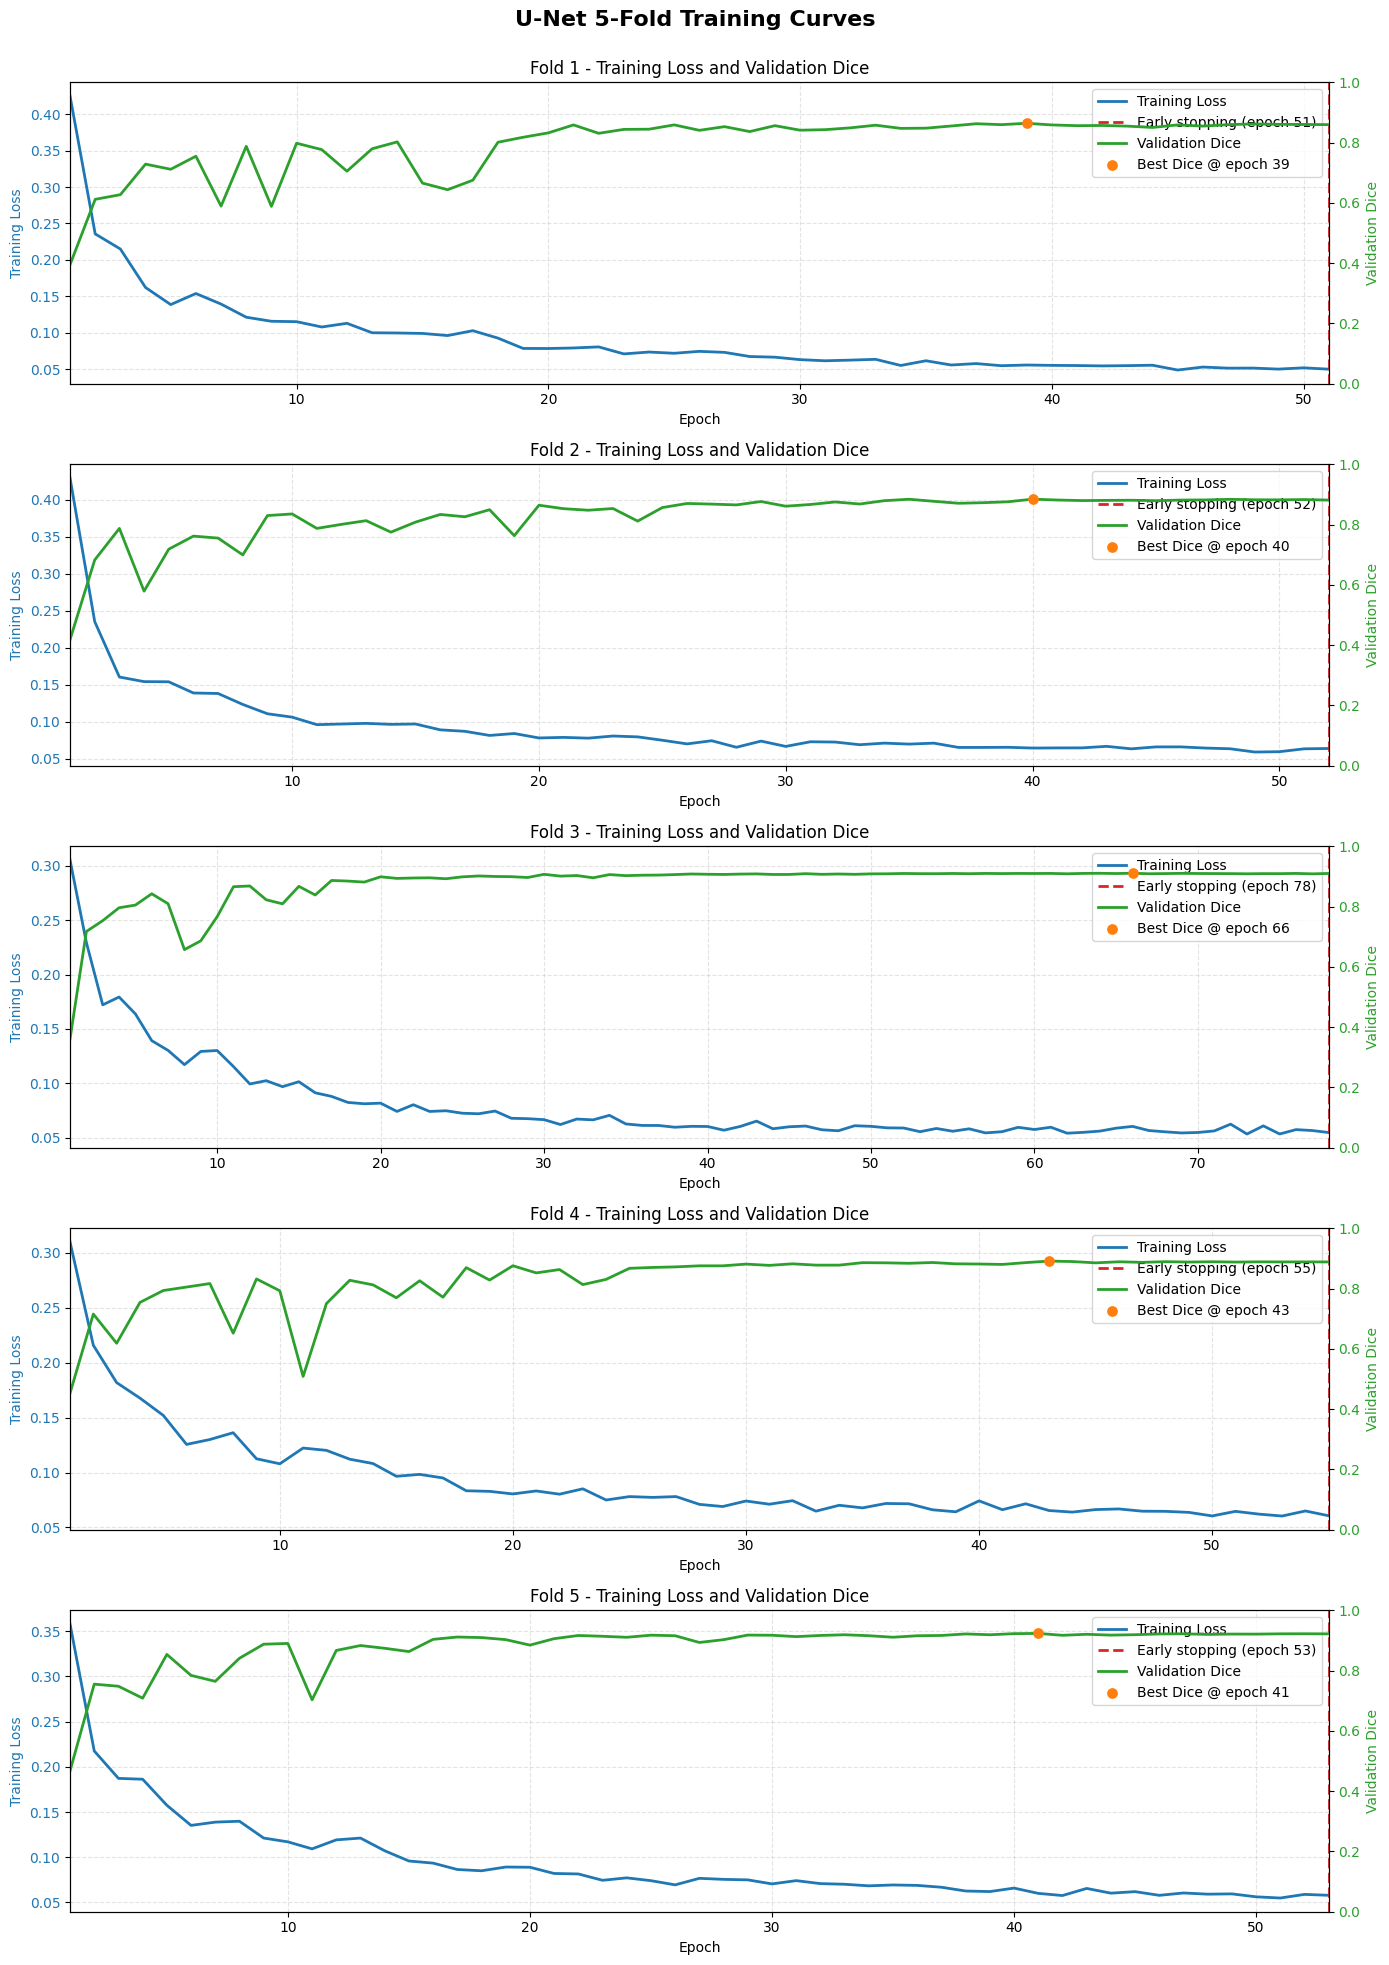

: 

In [ ]:
import json
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np

history_dir = Path("unet_training_history")
history_files = sorted(history_dir.glob("fold_*_history.json"))

if "fold_histories" in globals() and fold_histories:
    histories = fold_histories
elif history_files:
    histories = [json.loads(path.read_text(encoding="utf-8")) for path in history_files]
else:
    raise RuntimeError("No fold histories found. Run the K-fold training cell first so the notebook can save them.")

num_folds = len(histories)
fig, axes = plt.subplots(num_folds, 1, figsize=(14, 4 * num_folds), sharex=False)

if num_folds == 1:
    axes = [axes]

for ax, fold_data in zip(axes, histories):
    epochs = np.arange(1, len(fold_data["train_loss"]) + 1)
    train_loss = fold_data["train_loss"]
    val_dice = fold_data["val_dice"]
    early_stop_epoch = fold_data.get("early_stop_epoch")
    best_epoch = fold_data.get("best_epoch", 0)
    best_dice = fold_data.get("best_dice", 0.0)

    ax_loss = ax
    ax_dice = ax.twinx()

    loss_line = ax_loss.plot(epochs, train_loss, color="#1f77b4", linewidth=2.0, label="Training Loss")
    dice_line = ax_dice.plot(epochs, val_dice, color="#2ca02c", linewidth=2.0, label="Validation Dice")

    if early_stop_epoch is not None:
        ax_loss.axvline(
            early_stop_epoch,
            color="#d62728",
            linestyle="--",
            linewidth=2.0,
            label=f"Early stopping (epoch {early_stop_epoch})",
        )

    if best_epoch > 0:
        ax_dice.scatter(
            [best_epoch],
            [best_dice],
            color="#ff7f0e",
            s=45,
            zorder=5,
            label=f"Best Dice @ epoch {best_epoch}",
        )

    ax_loss.set_title(f"Fold {fold_data['fold']} - Training Loss and Validation Dice")
    ax_loss.set_xlabel("Epoch")
    ax_loss.set_ylabel("Training Loss", color="#1f77b4")
    ax_dice.set_ylabel("Validation Dice", color="#2ca02c")
    ax_loss.tick_params(axis="y", labelcolor="#1f77b4")
    ax_dice.tick_params(axis="y", labelcolor="#2ca02c")
    ax_loss.grid(True, linestyle="--", alpha=0.35)
    ax_loss.set_xlim(1, max(epochs))
    ax_dice.set_ylim(0.0, 1.0)

    handles1, labels1 = ax_loss.get_legend_handles_labels()
    handles2, labels2 = ax_dice.get_legend_handles_labels()
    ax_loss.legend(handles1 + handles2, labels1 + labels2, loc="best")

fig.suptitle("U-Net 5-Fold Training Curves", fontsize=16, fontweight="bold")
fig.tight_layout(rect=[0, 0, 1, 0.98])
plt.savefig("unet_5fold_training_curves.png", dpi=300, bbox_inches="tight")
plt.show()


Ringkasan training dari history tersimpan
 Fold  Loss akhir pelatihan  Best Dice  Epoch early stopping
    1              0.049916   0.864142                    51
    2              0.063636   0.884471                    52
    3              0.054734   0.910741                    78
    4              0.060684   0.891368                    55
    5              0.057943   0.923394                    53

Loss akhir (Lseg): 0.0574 ± 0.0048 | Dice Score: 0.8948 ± 0.0206 | Epoch early stopping: 57.8 ± 10.2

Per-view Dice will be computed over 36 held-out test masks.

Tabel 4.4 — Dice Score U-Net per Sudut Pandang pada Held-Out Test Set
      Sudut Pandang  n  Dice mean  Dice std
   Anterior (Front)  7   0.922586  0.036851
Right Oblique (45°)  8   0.939199  0.022087
 Left Oblique (45°)  7   0.921143  0.022414
Right Lateral (90°)  8   0.867517  0.082768
 Left Lateral (90°)  6   0.878428  0.084357


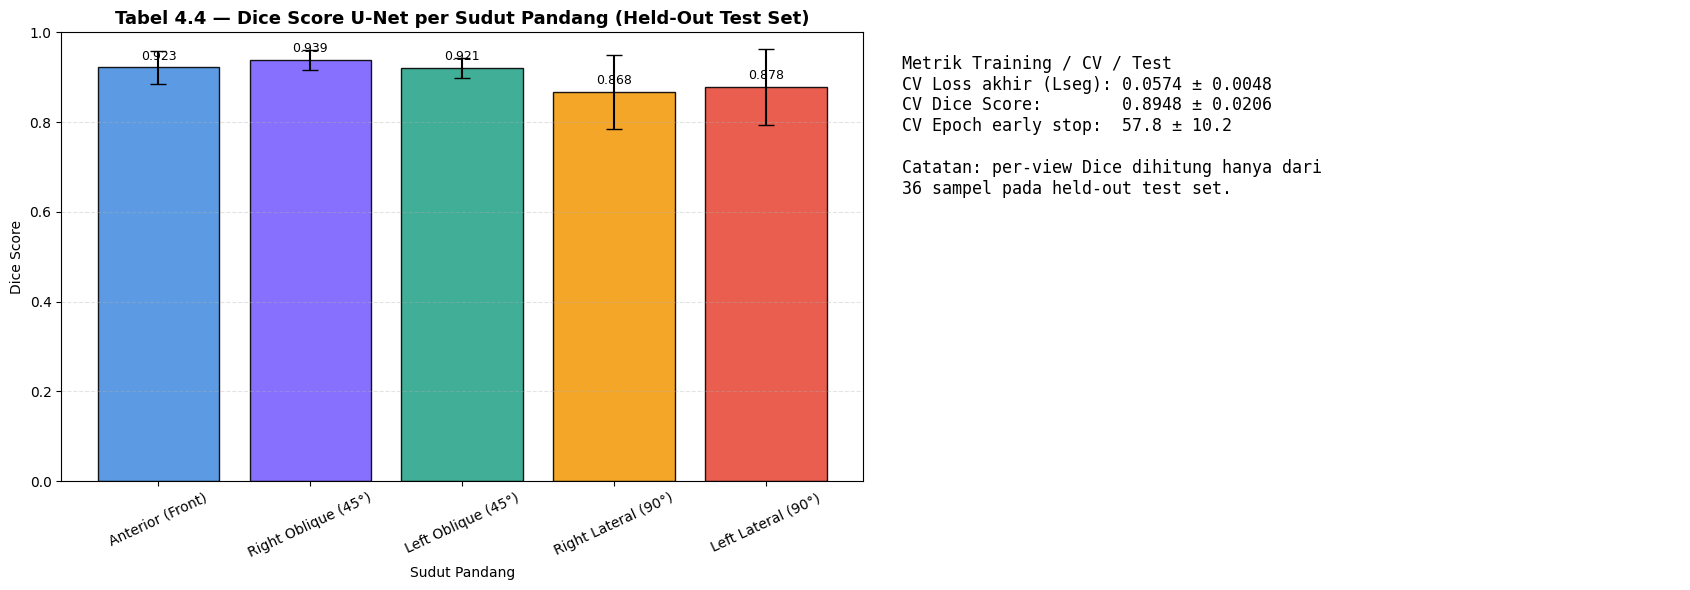

In [22]:
import json
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

history_dir = Path("unet_training_history")
history_files = sorted(history_dir.glob("fold_*_history.json"))
if not history_files:
    raise RuntimeError("No fold history JSON files found. Run the K-fold training cell first.")

histories = [json.loads(path.read_text(encoding="utf-8")) for path in history_files]
history_df = pd.DataFrame(
    {
        "Fold": [item["fold"] for item in histories],
        "Loss akhir pelatihan": [item["train_loss"][-1] for item in histories],
        "Best Dice": [item["best_dice"] for item in histories],
        "Epoch early stopping": [item["early_stop_epoch"] for item in histories],
    }
)

loss_mean = history_df["Loss akhir pelatihan"].mean()
loss_std = history_df["Loss akhir pelatihan"].std(ddof=0)
dice_mean = history_df["Best Dice"].mean()
dice_std = history_df["Best Dice"].std(ddof=0)
early_stop_mean = history_df["Epoch early stopping"].mean()
early_stop_std = history_df["Epoch early stopping"].std(ddof=0)

print("\nRingkasan training dari history tersimpan")
print(history_df.to_string(index=False))
print(
    f"\nLoss akhir (Lseg): {loss_mean:.4f} ± {loss_std:.4f} | "
    f"Dice Score: {dice_mean:.4f} ± {dice_std:.4f} | "
    f"Epoch early stopping: {early_stop_mean:.1f} ± {early_stop_std:.1f}"
)

# FIX: restrict per-view Dice table to the held-out test_set only.
# Extract the mask paths that belong to test_set so we do not mix in training patients.
test_mask_paths = {full_dataset.mask_paths[i] for i in test_set.indices}
print(f"\nPer-view Dice will be computed over {len(test_mask_paths)} held-out test masks.")

pred_root = Path(OUTPUT_UNET_DIR)
gt_root = Path(MASK_BASE)
view_specs = [
    ("Anterior (Front)", ["Anterior", "Front"]),
    ("Right Oblique (45°)", ["Right", "Oblique", "45"]),
    ("Left Oblique (45°)", ["Left", "Oblique", "45"]),
    ("Right Lateral (90°)", ["Right", "Lateral", "90"]),
    ("Left Lateral (90°)", ["Left", "Lateral", "90"]),
]


def load_binary_mask(path):
    image = cv2.imread(str(path), cv2.IMREAD_GRAYSCALE)
    if image is None:
        return None
    return (image > 127).astype(np.uint8)


def dice_score(mask_a, mask_b):
    intersection = np.logical_and(mask_a, mask_b).sum()
    denominator = mask_a.sum() + mask_b.sum()
    return float((2.0 * intersection + 1e-6) / (denominator + 1e-6))


rows = []
for view_label, tokens in view_specs:
    scores = []
    for gt_path in gt_root.rglob("*.png"):
        # Skip any GT mask that was not assigned to test_set
        if str(gt_path) not in test_mask_paths:
            continue

        gt_name = gt_path.name.replace("Â", "")
        if not all(token.lower() in gt_name.lower() for token in tokens):
            continue

        rel_path = gt_path.relative_to(gt_root)
        pred_dir = pred_root / rel_path.parent
        if not pred_dir.exists():
            continue

        pred_path = None
        for candidate in pred_dir.glob("*_unet_mask.png"):
            candidate_name = candidate.name.replace("_unet_mask.png", "").replace("Â", "")
            if all(token.lower() in candidate_name.lower() for token in tokens):
                pred_path = candidate
                break

        if pred_path is None:
            continue

        gt_mask   = load_binary_mask(gt_path)
        pred_mask = load_binary_mask(pred_path)
        if gt_mask is None or pred_mask is None:
            continue

        if gt_mask.shape != pred_mask.shape:
            pred_mask = cv2.resize(pred_mask, (gt_mask.shape[1], gt_mask.shape[0]), interpolation=cv2.INTER_NEAREST)

        scores.append(dice_score(pred_mask, gt_mask))

    rows.append(
        {
            "Sudut Pandang": view_label,
            "n": len(scores),
            "Dice mean": float(np.mean(scores)) if scores else np.nan,
            "Dice std": float(np.std(scores, ddof=0)) if scores else np.nan,
        }
    )


dice_table = pd.DataFrame(rows)
print("\nTabel 4.4 — Dice Score U-Net per Sudut Pandang pada Held-Out Test Set")
print(dice_table.to_string(index=False))
dice_table.to_csv("Tabel_4_4_Dice_Score_UNet_Set_Uji.csv", index=False)

fig, axes = plt.subplots(1, 2, figsize=(17, 6))

bars = axes[0].bar(
    dice_table["Sudut Pandang"],
    dice_table["Dice mean"],
    yerr=dice_table["Dice std"],
    capsize=6,
    color=["#4A90E2", "#7B61FF", "#2CA58D", "#F39C12", "#E74C3C"],
    edgecolor="black",
    alpha=0.9,
)
axes[0].set_title("Tabel 4.4 — Dice Score U-Net per Sudut Pandang (Held-Out Test Set)", fontsize=13, fontweight="bold")
axes[0].set_xlabel("Sudut Pandang")
axes[0].set_ylabel("Dice Score")
axes[0].set_ylim(0.0, 1.0)
axes[0].tick_params(axis="x", rotation=25)
axes[0].grid(axis="y", linestyle="--", alpha=0.35)
for bar, score in zip(bars, dice_table["Dice mean"]):
    if np.isfinite(score):
        axes[0].text(bar.get_x() + bar.get_width() / 2, score + 0.01, f"{score:.3f}", ha="center", va="bottom", fontsize=9)

axes[1].axis("off")
summary_text = (
    f"Metrik Training / CV / Test\n"
    f"CV Loss akhir (Lseg): {loss_mean:.4f} ± {loss_std:.4f}\n"
    f"CV Dice Score:        {dice_mean:.4f} ± {dice_std:.4f}\n"
    f"CV Epoch early stop:  {early_stop_mean:.1f} ± {early_stop_std:.1f}\n\n"
    f"Catatan: per-view Dice dihitung hanya dari\n"
    f"{len(test_mask_paths)} sampel pada held-out test set."
)
axes[1].text(0.03, 0.95, summary_text, va="top", ha="left", fontsize=12, family="monospace")

plt.tight_layout()
plt.savefig("unet_test_metrics_and_table44.png", dpi=300, bbox_inches="tight")
plt.show()


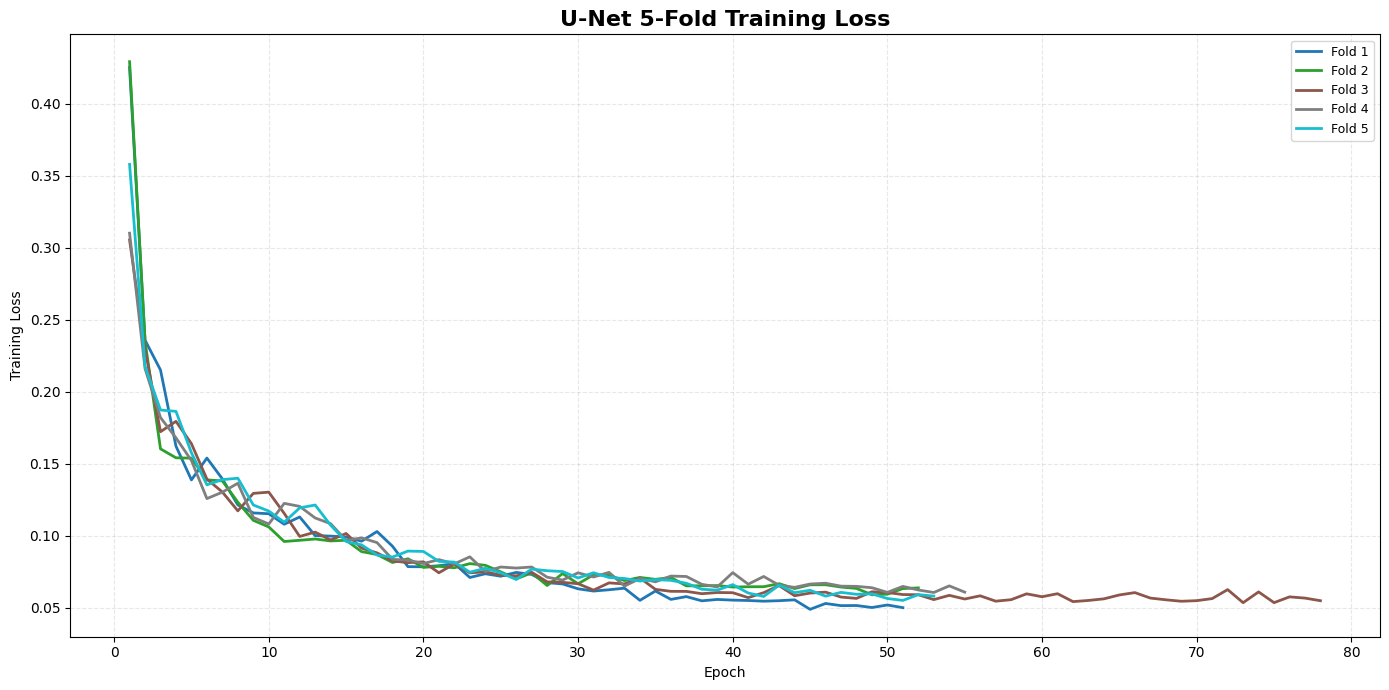

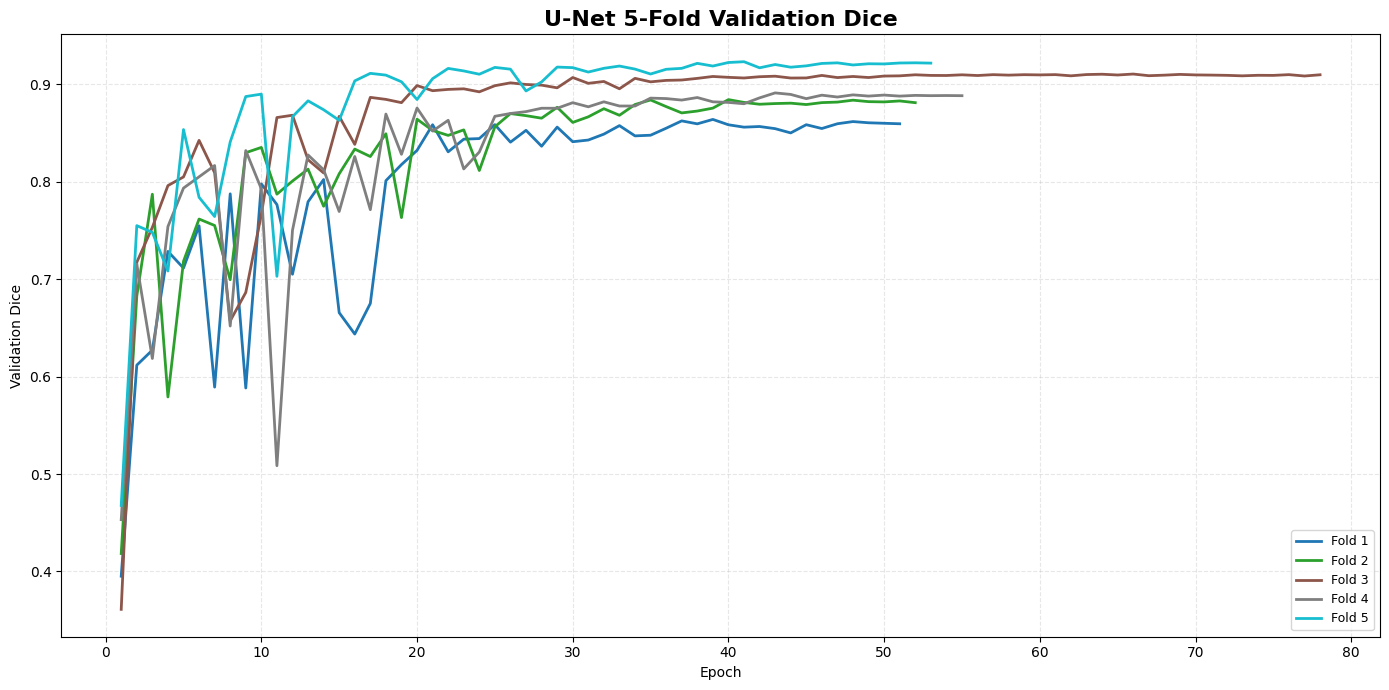

In [2]:
import json
import glob
import os

import matplotlib.pyplot as plt
import numpy as np

history_dir = "/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/finalized/Stage 2/unet_training_history"
history_paths = sorted(
    glob.glob(os.path.join(history_dir, "fold_*_history.json")),
    key=lambda path: int(os.path.basename(path).split("_")[1]),
)

if not history_paths:
    raise FileNotFoundError(f"No history JSON files found in {history_dir}")

colors = plt.cm.tab10(np.linspace(0, 1, len(history_paths)))

# Training loss figure
fig_loss, ax_loss = plt.subplots(figsize=(14, 7))
for color, history_path in zip(colors, history_paths):
    with open(history_path, "r", encoding="utf-8") as handle:
        fold_data = json.load(handle)

    fold_number = int(os.path.basename(history_path).split("_")[1])
    fold_name = f"Fold {fold_number}"
    epochs = np.arange(1, len(fold_data["train_loss"]) + 1)

    ax_loss.plot(
        epochs,
        fold_data["train_loss"],
        color=color,
        linewidth=2.0,
        label=fold_name,
    )

ax_loss.set_title("U-Net 5-Fold Training Loss", fontsize=16, fontweight="bold")
ax_loss.set_xlabel("Epoch")
ax_loss.set_ylabel("Training Loss")
ax_loss.grid(True, alpha=0.3, linestyle="--")
ax_loss.legend(loc="upper right", fontsize=9, frameon=True)
fig_loss.tight_layout()
loss_output_path = "/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/finalized/Stage 2/unet_training_loss.png"
fig_loss.savefig(loss_output_path, dpi=300, bbox_inches="tight")
plt.show()

# Validation Dice figure
fig_dice, ax_dice = plt.subplots(figsize=(14, 7))
for color, history_path in zip(colors, history_paths):
    with open(history_path, "r", encoding="utf-8") as handle:
        fold_data = json.load(handle)

    fold_number = int(os.path.basename(history_path).split("_")[1])
    fold_name = f"Fold {fold_number}"
    epochs = np.arange(1, len(fold_data["val_dice"]) + 1)

    ax_dice.plot(
        epochs,
        fold_data["val_dice"],
        color=color,
        linewidth=2.0,
        label=fold_name,
    )

ax_dice.set_title("U-Net 5-Fold Validation Dice", fontsize=16, fontweight="bold")
ax_dice.set_xlabel("Epoch")
ax_dice.set_ylabel("Validation Dice")
ax_dice.grid(True, alpha=0.3, linestyle="--")
ax_dice.legend(loc="lower right", fontsize=9, frameon=True)
fig_dice.tight_layout()
dice_output_path = "/mnt/Data1/Peoples/faiz836b/DNP-3DDMR-IR/finalized/Stage 2/unet_validation_dice.png"
fig_dice.savefig(dice_output_path, dpi=300, bbox_inches="tight")
plt.show()